In [2]:
# imports
import sys
import os
import gc
sys.path.insert(0, os.path.abspath(os.path.join('profiler')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from tqdm import tqdm
from HamDiv import diversity as hamdiv
from profiler.prop_profiler.prop_profiler import profile_molecules

import utils

fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=3, fpSize=2048, includeChirality=True
)


In [ ]:
## Helper functions
def load_enumeration_results_from_directory(directory):
    '''
        Load multiple enumeration results from a directory. This will read all 
        csv files existing in the directory.

        Args:
            directory (str): The directory containing the enumeration result files.

        Returns:
            pd.DataFrame: A DataFrame containing the combined enumeration results.

        Raises:
            FileNotFoundError: If the directory does not exist.
            ValueError: If no enumeration result files are found in the directory.
    '''
    if not os.path.exists(directory):
        raise FileNotFoundError(f"The directory '{directory}' does not exist.")
    
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    if not csv_files:
        raise ValueError(f"No enumeration result files found in the directory '{directory}'.")
    
    dataframes = []
    for file in csv_files:
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        dataframes.append(df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

def others_to_healer_result_format(df: pd.DataFrame, incoming_frmt: str='chemprojector'):
    '''
        Convert the result format of other enumerators to the one used by Healer.

        Args:
            df (pd.DataFrame): DataFrame containing the enumerated compounds.
            incoming_frmt (str): Format of the incoming DataFrame. 
                - chemprojector
                - synformer

        Returns:
            pd.DataFrame: DataFrame in Healer's result format. The output will include the additional columns:
                - 'Product': SMILES of the enumerated compound.
                - 'num_steps': Number of steps taken to enumerate the compound.
                - 'Similarity_to_query': Similarity of the enumerated compound to the query compound.
                - 'ID': Unique identifier for the enumerated compound as in healer.
    '''
    if incoming_frmt in ['chemprojector', 'synformer']:
        targets = df['target'].unique()
        # output_df = pd.DataFrame(columns=['smiles', 'num_steps', 'Similarity_to_query'])
        output_dfs = []
        for target in targets:
            target_df = df[df['target'] == target]
            tmp = pd.DataFrame({'target': [target], 'smiles': [target]})
            target_df = pd.concat([tmp, target_df], axis=0)
            fps = [fp_generator.GetFingerprint(Chem.MolFromSmiles(smi)) for smi in target_df['smiles'].values]
            tani_sims = Chem.DataStructs.BulkTanimotoSimilarity(fps[0], fps)
            target_df['Similarity_to_query'] = np.round(tani_sims, 2)
            target_df = target_df[['smiles', 'num_steps', 'Similarity_to_query']].sort_values(
                by='Similarity_to_query', ascending=False
            ).reset_index(drop=True)
            target_df['ID'] = [f'HEAL_{i:06d}' for i in range(len(target_df))]
            target_df = target_df.rename(columns={'smiles': 'Product'})
            output_dfs.append(target_df)
            # output_df = pd.concat([output_df, target_df], axis=0)
    
    return pd.concat(output_dfs, axis=0)

def get_top_n_dfs(data, n=[0, 1, 10, 25]) -> list[pd.DataFrame]:
    '''
        Get the best scoring n enumerations for each query. If n=0,
        return the query molecules.

        Args:
            data (pd.DataFrame): The DataFrame containing the enumeration results.
            n (list): A list of integers representing the number of top enumerations to retrieve.
                Default is [0, 1, 10, 25]. If n=0, the query molecules are returned.

        Returns:
            list: A list of DataFrames, each containing the top n enumerations for each query.
            pd.DataFrame: A DataFrame containing the smallest subset of that contains 
                the largest n with query.
    '''
    n = sorted(n)
    smallest_subset = data[data['ID'].isin([f'HEAL_{i:06d}' for i in range(0, max(n) + 1)])].copy()
    smallest_subset['SA_score'] = [utils.get_sascore(x) for x in smallest_subset['Product'].values]
    prop_data = profile_molecules(smallest_subset['Product'].values, device='cuda', verbose=True)
    prop_data = prop_data.rename(columns={'smiles': 'Product'})
    smallest_subset = pd.merge(
        smallest_subset, prop_data, how='left', on='Product'
    )
    top_n_dfs = []
    for n_val in n:
        if n_val == 0:   
            top_n_df = smallest_subset[smallest_subset['ID'] == 'HEAL_000000'].copy()
            top_n_df.name = 'Query'
        else:
            top_n_df = smallest_subset[smallest_subset['ID'].isin([f'HEAL_{i:06d}' for i in range(1, n_val + 1)])].copy()
            top_n_df.name = f'Top-{n_val}'
        top_n_dfs.append(top_n_df)

    return top_n_dfs, smallest_subset

def calculate_statistics(dfs, top_n_partitions):
    '''
        Calculate the success rate, reconstruction rate, and top_n_average similarity.

        Args:
            dfs (list): A list of DataFrames containing the top-n datasets. 
            top_n_partitions (list): A list of integers representing the number of 
                top enumerations to consider. should be same order as dfs.

        Returns:
            dict: A dictionary containing the calculated statistics.
                - 'Success Rate': The ratio of successful enumerations to total enumerations.
                - 'Reconstruction Rate': The ratio of successfully reconstructed enumerations to total enumerations.
                - 'Top n Average Similarity': The average similarity of the top n enumerations.
                - 'Number of Rxn Steps (Top n)': The average number of reaction steps for the top n enumerations.
                - 'Average Diversity': The average diversity of the top n enumerations.
            dict: A dictionary containing the diversity calculations for each enumeration.
                - 'Top n Diversity': The diversity scores for the top n enumerations.
    '''
    if len(dfs) != len(top_n_partitions):
        raise ValueError("The length of dfs and top_n_partitions must be the same.")
    top0_idx = top_n_partitions.index(0)
    top1_idx = top_n_partitions.index(1)
    reconstructed = dfs[top1_idx][dfs[top1_idx]['Similarity_to_query'] == 1.0]
    statistics = {
        'Success Rate': len(dfs[top1_idx]) / len(dfs[top0_idx]),
        'Reconstruction Rate': len(reconstructed) / len(dfs[top0_idx]),
    }
    diversity_outputs = {} # diversity outputs for each enumeration
    similarity_outputs = {} # similarity outputs for each enumeration
    for i, n in tqdm(enumerate(top_n_partitions), total=len(top_n_partitions)):
        if n == 0:
            continue
        # statistics[f'Top {n} Average Similarity'] = dfs[i]['Similarity_to_query'].mean()
        statistics[f'Number of Rxn Steps (Top {n})'] = dfs[i]['num_steps'].mean()
        enum_starts = [idx for idx, x in enumerate(dfs[i]['ID']) if x == 'HEAL_000001']
        smiles = dfs[i]['Product'].values
        similarities = dfs[i]['Similarity_to_query'].values
        divs = []
        sims = []
        weights = []
        for k in range(len(enum_starts) - 1):
            if enum_starts[-1] == enum_starts[k + 1]:
                enums_k = smiles[enum_starts[k]:]
                sims_k = similarities[enum_starts[k]:]
            else:
                enums_k = smiles[enum_starts[k]:enum_starts[k + 1]]
                sims_k = similarities[enum_starts[k]:enum_starts[k + 1]]
            weights.append(len(enums_k))
            sims.append(np.mean(sims_k))
            if len(enums_k) > 1:
                divs.append(get_diversity_score(enums_k, mode='HamDiv'))
            else:
                divs.append(0)
        divs = np.array(divs)
        sims = np.array(sims)
        statistics[f'Top {n} Average Similarity'] = np.average(sims, weights=weights)
        statistics[f'Top {n} Average Diversity'] = np.average(divs, weights=weights)
        diversity_outputs[f'Top {n} Diversity'] = divs
        similarity_outputs[f'Top {n} Similarity'] = sims

    return statistics, diversity_outputs, similarity_outputs

def get_optimization_stats(subset_df, n=100):
    '''
        Get the optimization statistics for a subset of enumerated compounds.

        Args:
            subset_df (pd.DataFrame): DataFrame containing the enumerations and their properties.
            n (int): The number of enumerations to consider for optimization statistics. Default is 100.

        Returns:
            dict: A dictionary containing the optimization statistics, including:
                - 'stoplight_improvements': Average stoplight score improvements.
                - 'cns_mpo_improvements': Average CNS-MPO score improvements.
                - 'qed_improvements': Average QED score improvements.
                - 'improvement_counts': Counts of improvements from one stoplight color to another.
    '''
    stoplight_colors = subset_df['stoplight_colors'].values
    stoplight_scores = subset_df['stoplight_scores'].values
    cns_mpo_scores = subset_df['cns_mpo_score'].values
    qed_scores = subset_df['qed'].values
    query_idx = [idx for idx, x in enumerate(subset_df['ID']) if x == 'HEAL_000000']

    # Calculate the average stoplight score, CNS-MPO score, and QED score
    stoplight_improvements = []
    cns_mpo_improvements = []
    qed_improvements = []
    improvement_counts = {
        'red2green': [], 'red2yellow': [], 'red2red': [],
        'yellow2green': [], 'yellow2yellow': [], 'yellow2red': [],
        'green2green': [], 'green2yellow': [], 'green2red': [],
    }
    for k in range(len(query_idx) - 1):
        if query_idx[-1] == query_idx[k + 1]:
            start_idx = query_idx[k]
            query_color = stoplight_colors[start_idx]
            query_stoplight_score = stoplight_scores[start_idx]
            query_qed_score = qed_scores[start_idx]
            query_cns_mpo_score = cns_mpo_scores[start_idx]
            stoplights = stoplight_colors[start_idx+1:]
            stoplight_scores_enum = stoplight_scores[start_idx+1:]
            qed_scores_enum = qed_scores[start_idx+1:]
            cns_mpo_scores_enum = cns_mpo_scores[start_idx+1:]
        else:
            start_idx = query_idx[k]
            end_idx = query_idx[k + 1]
            query_color = stoplight_colors[start_idx]
            query_stoplight_score = stoplight_scores[start_idx]
            query_qed_score = qed_scores[start_idx]
            query_cns_mpo_score = cns_mpo_scores[start_idx]
            stoplights = stoplight_colors[start_idx+1:end_idx]
            stoplight_scores_enum = stoplight_scores[start_idx+1:end_idx]
            qed_scores_enum = qed_scores[start_idx+1:end_idx]
            cns_mpo_scores_enum = cns_mpo_scores[start_idx+1:end_idx]
        if len(stoplights) == 0:
            continue

        if query_color == 'red':
            improvement_counts['red2green'].append(len([1 for x in stoplights if x == 'green']) / len(stoplights))
            improvement_counts['red2yellow'].append(len([1 for x in stoplights if x == 'yellow']) / len(stoplights))
            improvement_counts['red2red'].append(len([1 for x in stoplights if x == 'red']) / len(stoplights))
        elif query_color == 'yellow':
            improvement_counts['yellow2green'].append(len([1 for x in stoplights if x == 'green']) / len(stoplights))
            improvement_counts['yellow2yellow'].append(len([1 for x in stoplights if x == 'yellow']) / len(stoplights))
            improvement_counts['yellow2red'].append(len([1 for x in stoplights if x == 'red']) / len(stoplights))
        elif query_color == 'green':
            improvement_counts['green2green'].append(len([1 for x in stoplights if x == 'green']) / len(stoplights))
            improvement_counts['green2yellow'].append(len([1 for x in stoplights if x == 'yellow']) / len(stoplights))
            improvement_counts['green2red'].append(len([1 for x in stoplights if x == 'red']) / len(stoplights))

        stoplight_improvements.append(
            np.mean(stoplight_scores_enum - query_stoplight_score)
        )
        cns_mpo_improvements.append(
            np.mean(cns_mpo_scores_enum - query_cns_mpo_score)
        )
        qed_improvements.append(
            np.mean(qed_scores_enum - query_qed_score)
        )

    improvement_dict = {
        'stoplight_improvements': np.array(stoplight_improvements),
        'cns_mpo_improvements': np.array(cns_mpo_improvements),
        'qed_improvements': np.array(qed_improvements),
    }
    improvement_dict.update(improvement_counts)

    return improvement_dict

def get_diversity_score(smiles, mode='HamDiv'):
    '''
        Calculate the diversity score of a list of SMILES strings.

        Args:
            smiles (list): A list of SMILES strings.
            mode (str): The method to calculate diversity. Options are
                HamDiv, FG, RS, BM, Richness, IntDiv, SumDiv, Diam, SumDiam,
                Bot, SumBot, DPP, and NCircles-0.x.

        Returns:
            float: The diversity score.
    '''
    if mode in ['FG', 'RS', 'BM', 'Richness']:
        return hamdiv.diversity_all(smiles, mode=mode)
    
    dists = get_pdist_matrix(smiles)
    if mode == 'HamDiv':
        n = len(smiles)
        comp_method = 'exact_dp' if n <= 5 else 'local_search' if n <= 20 else 'greedy_tsp'
        return hamdiv.HamDiv(smiles, dists=dists, method=comp_method)
    
    return hamdiv.diversity_all(smiles, dists=dists, mode=mode)

def get_pdist_matrix(smiles):
    '''
        Calculate the pairwise distance matrix for a list of SMILES strings.

        Args:
            smiles (list): A list of SMILES strings.

        Returns:
            np.ndarray: The pairwise distance matrix.
    '''
    fps = [fp_generator.GetFingerprint(Chem.MolFromSmiles(smi)) for smi in smiles]
    sims = np.zeros((len(smiles), len(smiles)))
    for i in range(len(smiles)):
        sims[i] = Chem.DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    return 1 - sims

def min_max_normalize(arr):
    '''
        Min-max normalization of an array.

        Args:
            arr (np.ndarray): The array to be normalized.

        Returns:
            np.ndarray: The normalized array.
    '''
    arr = np.array(arr)
    arr_min = np.min(arr)
    arr_max = np.max(arr)
    return (arr - arr_min) / (arr_max - arr_min)

def get_random_enumerations_from_results_file(results_file, n=3):
    '''
        Get three enumeration results from a file that contains 
        multiple enumeration results in Healer's format.

        Args:
            results_file (str): The path to the file containing enumeration results.
            n (int): The number of random enumerations to retrieve. Default is 3.

        Returns:
            list of pd.DataFrame: A list containing three DataFrames.
    '''
    enums = pd.read_csv(results_file)
    enums = enums[enums['Similarity_to_query'] > 0.3].reset_index(drop=True)
    query_indices = list(enums[enums['ID'] == 'HEAL_000001'].index)
    query_indices = [i-1 for i in query_indices] + [len(enums) - 1]
    random_query_indices = np.random.randint(
        0, len(query_indices) - 1, size=n
    )
    random_enumerations = []
    for idx in random_query_indices:
        start_idx = query_indices[idx]
        end_idx = query_indices[idx + 1]
        random_enumerations.append(enums.iloc[start_idx:end_idx].reset_index(drop=True))
    return random_enumerations


# Enumerations Results


In [3]:
## load enumerations of benchmark datasets
sim_cutoff = 0.30
top_n_partitions = [0, 1, 5, 10, 25, 50, 100]

## HEALER results
# Enamine REAL 1k random
enums = pd.read_csv('healer_results/healer_enamine_1k_random_enums.csv')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
enums['num_steps'] = [1] * len(enums)
healer_enamine_dfs, healer_enamine_subset = get_top_n_dfs(enums, n=top_n_partitions)
healer_enamine_stats, healer_enamine_diversities, healer_enamine_similarities = calculate_statistics(healer_enamine_dfs, top_n_partitions)

# ChEMBL Ro5 1k random
enums = pd.read_csv('healer_results/healer_chembl_1k_random_enums.csv')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
enums['num_steps'] = [1] * len(enums)
healer_chembl_dfs, healer_chembl_subset = get_top_n_dfs(enums, n=top_n_partitions)
healer_chembl_stats, healer_chembl_diversities, healer_chembl_similarities = calculate_statistics(healer_chembl_dfs, top_n_partitions)

# ASKCOS Unsynthesizable 1k random
enums = pd.read_csv('healer_results/healer_askcos_unsynthesizable_1k_random_enums.csv')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
enums['num_steps'] = [1] * len(enums)
healer_askcos_dfs, healer_askcos_subset = get_top_n_dfs(enums, n=top_n_partitions)
healer_askcos_stats, healer_askcos_diversities, healer_askcos_similarities = calculate_statistics(healer_askcos_dfs, top_n_partitions)

## ChemProjector results
# Enamine REAL 1k random
enums = pd.read_csv(
    'chemprojector_results/chemprojector_enamine_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
chemprojector_enamine_dfs, chemprojector_enamine_subset = get_top_n_dfs(enums, n=top_n_partitions)
chemprojector_enamine_stats, chemprojector_enamine_diversities, chemprojector_enamine_similarities = calculate_statistics(chemprojector_enamine_dfs, top_n_partitions)

# ChEMBL Ro5 1k random
enums = pd.read_csv(
    'chemprojector_results/chemprojector_chembl_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
chemprojector_chembl_dfs, chemprojector_chembl_subset = get_top_n_dfs(enums, n=top_n_partitions)
chemprojector_chembl_stats, chemprojector_chembl_diversities, chemprojector_chembl_similarities = calculate_statistics(chemprojector_chembl_dfs, top_n_partitions)

# ASKCOS Unsynthesizable 1k random
enums = pd.read_csv(
    'chemprojector_results/chemprojector_askcos_unsynthesizable_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
chemprojector_askcos_dfs, chemprojector_askcos_subset = get_top_n_dfs(enums, n=top_n_partitions)
chemprojector_askcos_stats, chemprojector_askcos_diversities, chemprojector_askcos_similarities = calculate_statistics(chemprojector_askcos_dfs, top_n_partitions)

## Synformer results
# Enamine REAL 1k random
enums = pd.read_csv(
    'synformer_results/synformer_enamine_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
synformer_enamine_dfs, synformer_enamine_subset = get_top_n_dfs(enums, n=top_n_partitions)
synformer_enamine_stats, synformer_enamine_diversities, synformer_enamine_similarities = calculate_statistics(synformer_enamine_dfs, top_n_partitions)

# ChEMBL Ro5 1k random
enums = pd.read_csv(
    'synformer_results/synformer_chembl_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
synformer_chembl_dfs, synformer_chembl_subset = get_top_n_dfs(enums, n=top_n_partitions)
synformer_chembl_stats, synformer_chembl_diversities, synformer_chembl_similarities = calculate_statistics(synformer_chembl_dfs, top_n_partitions)

# ASKCOS Unsynthesizable 1k random
enums = pd.read_csv(
    'synformer_results/synformer_askcos_unsynthesizable_1k_random_enums.csv',
    usecols=['target', 'smiles', 'num_steps']
)
enums = others_to_healer_result_format(enums, incoming_frmt='chemprojector')
enums = enums[enums['Similarity_to_query'] > sim_cutoff]
synformer_askcos_dfs, synformer_askcos_subset = get_top_n_dfs(enums, n=top_n_partitions)
synformer_askcos_stats, synformer_askcos_diversities, synformer_askcos_similarities = calculate_statistics(synformer_askcos_dfs, top_n_partitions)

del enums
gc.collect()

Loading duration: 3.54 seconds
Filtering duration: 0.10 seconds
Adding num_steps duration: 0.25 seconds


Predicting: 305it [00:00, 11671.47it/s]            
Predicting: 305it [00:00, 7644.74it/s]             


Getting top n dfs duration: 1349.82 seconds


100%|██████████| 7/7 [00:26<00:00,  3.82s/it]
Predicting: 260it [00:00, 11478.66it/s]            
Predicting: 260it [00:00, 7737.09it/s]             
100%|██████████| 7/7 [00:24<00:00,  3.50s/it]
Predicting: 87it [00:00, 10993.75it/s]            
Predicting: 87it [00:00, 7529.24it/s]             
100%|██████████| 7/7 [00:08<00:00,  1.22s/it]
Predicting: 101it [00:00, 10978.43it/s]            
Predicting: 101it [00:00, 7423.42it/s]             
100%|██████████| 7/7 [00:15<00:00,  2.16s/it]
Predicting: 64it [00:00, 11260.35it/s]            
Predicting: 64it [00:00, 7481.27it/s]             
100%|██████████| 7/7 [00:10<00:00,  1.56s/it]
Predicting: 32it [00:00, 10760.66it/s]            
Predicting: 32it [00:00, 7626.87it/s]             
100%|██████████| 7/7 [00:04<00:00,  1.47it/s]
Predicting: 242it [00:00, 10904.13it/s]            
Predicting: 242it [00:00, 7308.41it/s]             
100%|██████████| 7/7 [00:28<00:00,  4.12s/it]
Predicting: 180it [00:00, 9905.46it/s]             
Predicti

0

# Comparison of Enumeration Statistics by Dataset and by Method


In [26]:
# multi-label table from dictionaries
def highlight_extremes(row, min_rows):
    styles = pd.Series("", index=row.index)
    prefer_min = row.name in min_rows

    # iterate over each Dataset group
    for ds in row.index.get_level_values(0).unique():
        sub = row[ds]  # Series indexed by Method
        target_value = sub.min() if prefer_min else sub.max()
        # bold all cells equal to the target
        mask = sub == target_value
        for method in sub.index:
            if mask.loc[method]:
                styles[(ds, method)] = "font-weight: bold"

    return styles

table_styles = [
    {# index names
        'selector': 'th.index_name:(.col_heading)',
        'props': 'font-style: italic; color: #323232; font-weight: bold; font-size: 12px; text-align: right;'
    },
    {# row index name
        'selector': 'th.index_name:not(.col_heading)',
        'props': 'font-style: italic; color: #323232; font-weight: bold; font-size: 12px; text-align: left;'
    },
    {# first level column headers
        'selector': 'th.col_heading.level0',
        'props': 'text-align: center; font-size: 16px; color: black'
    },
    {# second level column headers
        'selector': 'th.col_heading.level1',
        'props': 'font-size: 16px; font-weight: bold; text-align: center; color: black;'
    },
    {# header background
        'selector': 'thead th',
        'props': 'background-color: #0d97ff;' 
    },
    {# row headers
        'selector': 'th.row_heading',
        'props': 'text-align: left; font-size: 16px; font-weight: bold;'
    },
    {# even rows
        'selector': 'tbody tr:nth-child(even)',
        'props': 'background-color: #60bafd; color: black;'
    },
    {# odd rows
        'selector': 'tbody tr:nth-child(odd)',
        'props': 'background-color: #93d1ff; color: black;'
    },
]
multi_index = pd.MultiIndex.from_product(
    [['Enamine', 'ChEMBL', 'ASKCOS'], ['HEALER', 'ChemProjector', 'Synformer']],
    names=['Dataset', 'Method']
)
stats_df = pd.DataFrame(
    [healer_enamine_stats, chemprojector_enamine_stats, synformer_enamine_stats,
     healer_chembl_stats, chemprojector_chembl_stats, synformer_chembl_stats,
     healer_askcos_stats, chemprojector_askcos_stats, synformer_askcos_stats],
    index=multi_index,
).T
stats_df.index.name = 'Statistic'
s = stats_df.style\
    .format(precision=2)\
    .set_caption('Comparison of Methods on Different Datasets')\
    .set_table_styles(table_styles, overwrite=False)\
    .apply(highlight_extremes, axis=1, min_rows=[metric for metric in stats_df.index if 'Rxn Steps' in metric])
s.to_excel('summary_statistics.xlsx', engine='openpyxl', index=True, header=True)
s.to_html('summary_statistics.html', index=True, header=True, justify='center', border=0)
s


In [40]:
# get optimization statistics
subset_dfs = [
    healer_enamine_subset, chemprojector_enamine_subset, synformer_enamine_subset,
    healer_chembl_subset, chemprojector_chembl_subset, synformer_chembl_subset,
    healer_askcos_subset, chemprojector_askcos_subset, synformer_askcos_subset
]
optimization_statistics = []
for subset_df in subset_dfs:
    opt_stats = get_optimization_stats(subset_df)
    opt_stats = {k: np.nanmean(v) for k, v in opt_stats.items()}
    optimization_statistics.append(opt_stats)
opt_stats_df = pd.DataFrame(
    optimization_statistics,
    index=multi_index,
).T
opt_stats_df.index.name = 'Statistic'
s = opt_stats_df.style\
    .format(precision=2)\
    .set_caption('Comparison of Methods on Different Datasets by Optimization Metrics')\
    .set_table_styles(table_styles, overwrite=False)\
    .apply(highlight_extremes, axis=1, min_rows=[metric for metric in stats_df.index if 'Rxn Steps' in metric])
s.to_excel('optimization_statistics.xlsx', engine='openpyxl', index=True, header=True)
s.to_html('optimization_statistics.html', index=True, header=True, justify='center', border=0)
s


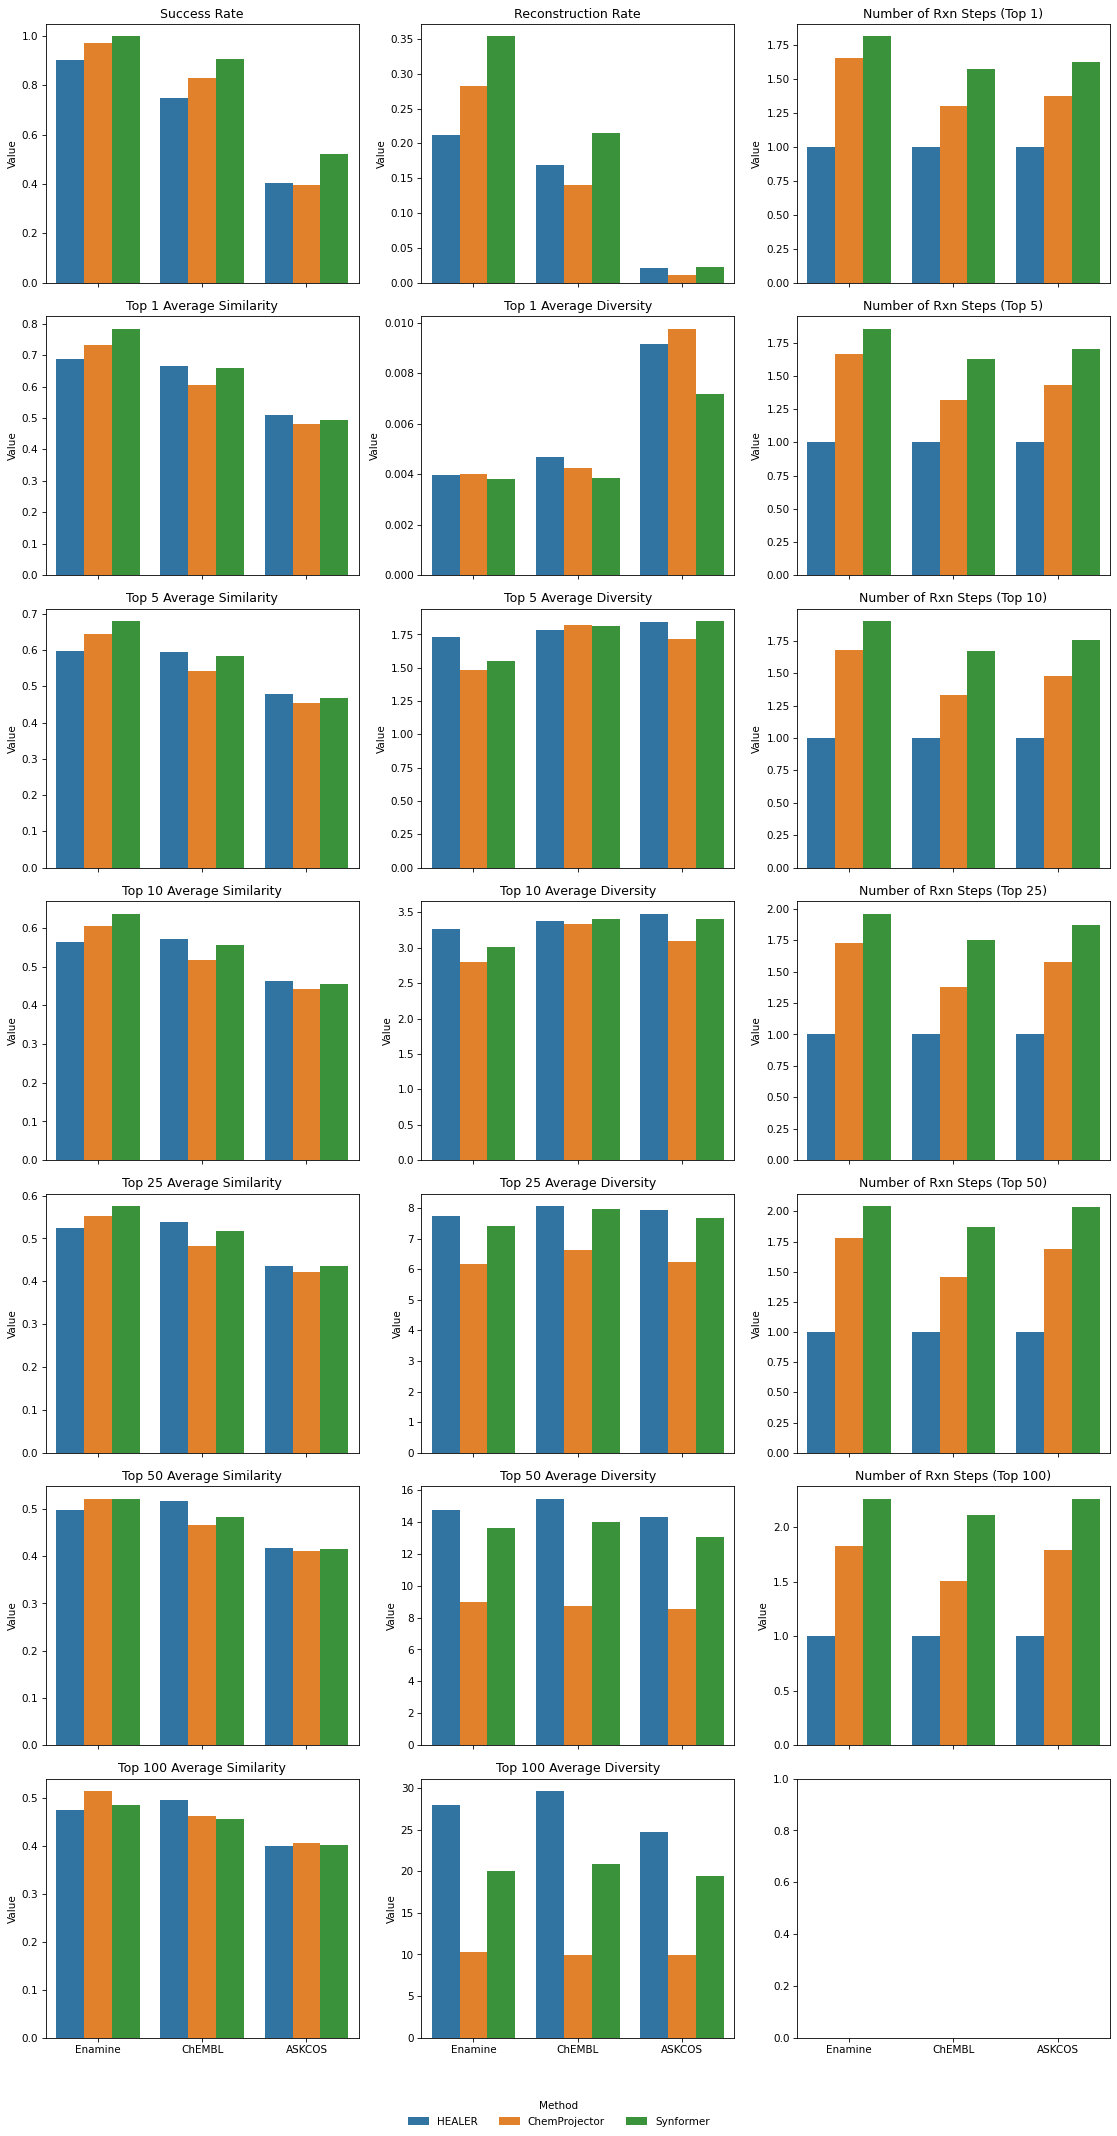

In [57]:
def plot_metric(ax, df_metric):
    # Draw grouped bars with seaborn
    sns.barplot(
        data=df_metric,
        x='Dataset',
        y='Value',
        hue='Method',
        ax=ax,
    )
    
    # Title & labels
    ax.set_title(df_metric['Statistic'].iloc[0])
    ax.set_ylabel("Value")
    ax.set_xlabel("")  # keep x-label clean
    
# melt the DataFrame for plotting
melt_df = stats_df.stack(level=['Dataset', 'Method'], future_stack=True).reset_index(name='Value')

stats = melt_df['Statistic'].unique()
n_stats = len(stats)

fig, axes = plt.subplots((n_stats//3)+1, 3, figsize=(15, 5*(n_stats//3)), sharex=True, dpi=75)
axes = axes.flatten()

for ax, stat in zip(axes, stats):
    subset = melt_df[melt_df['Statistic'] == stat]
    plot_metric(ax, subset)
    ax.legend_.remove()

# single legend at bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           title="Method",
           loc='lower center',
           ncol=len(labels),
           frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# SA Score Distributions by Method and by Dataset

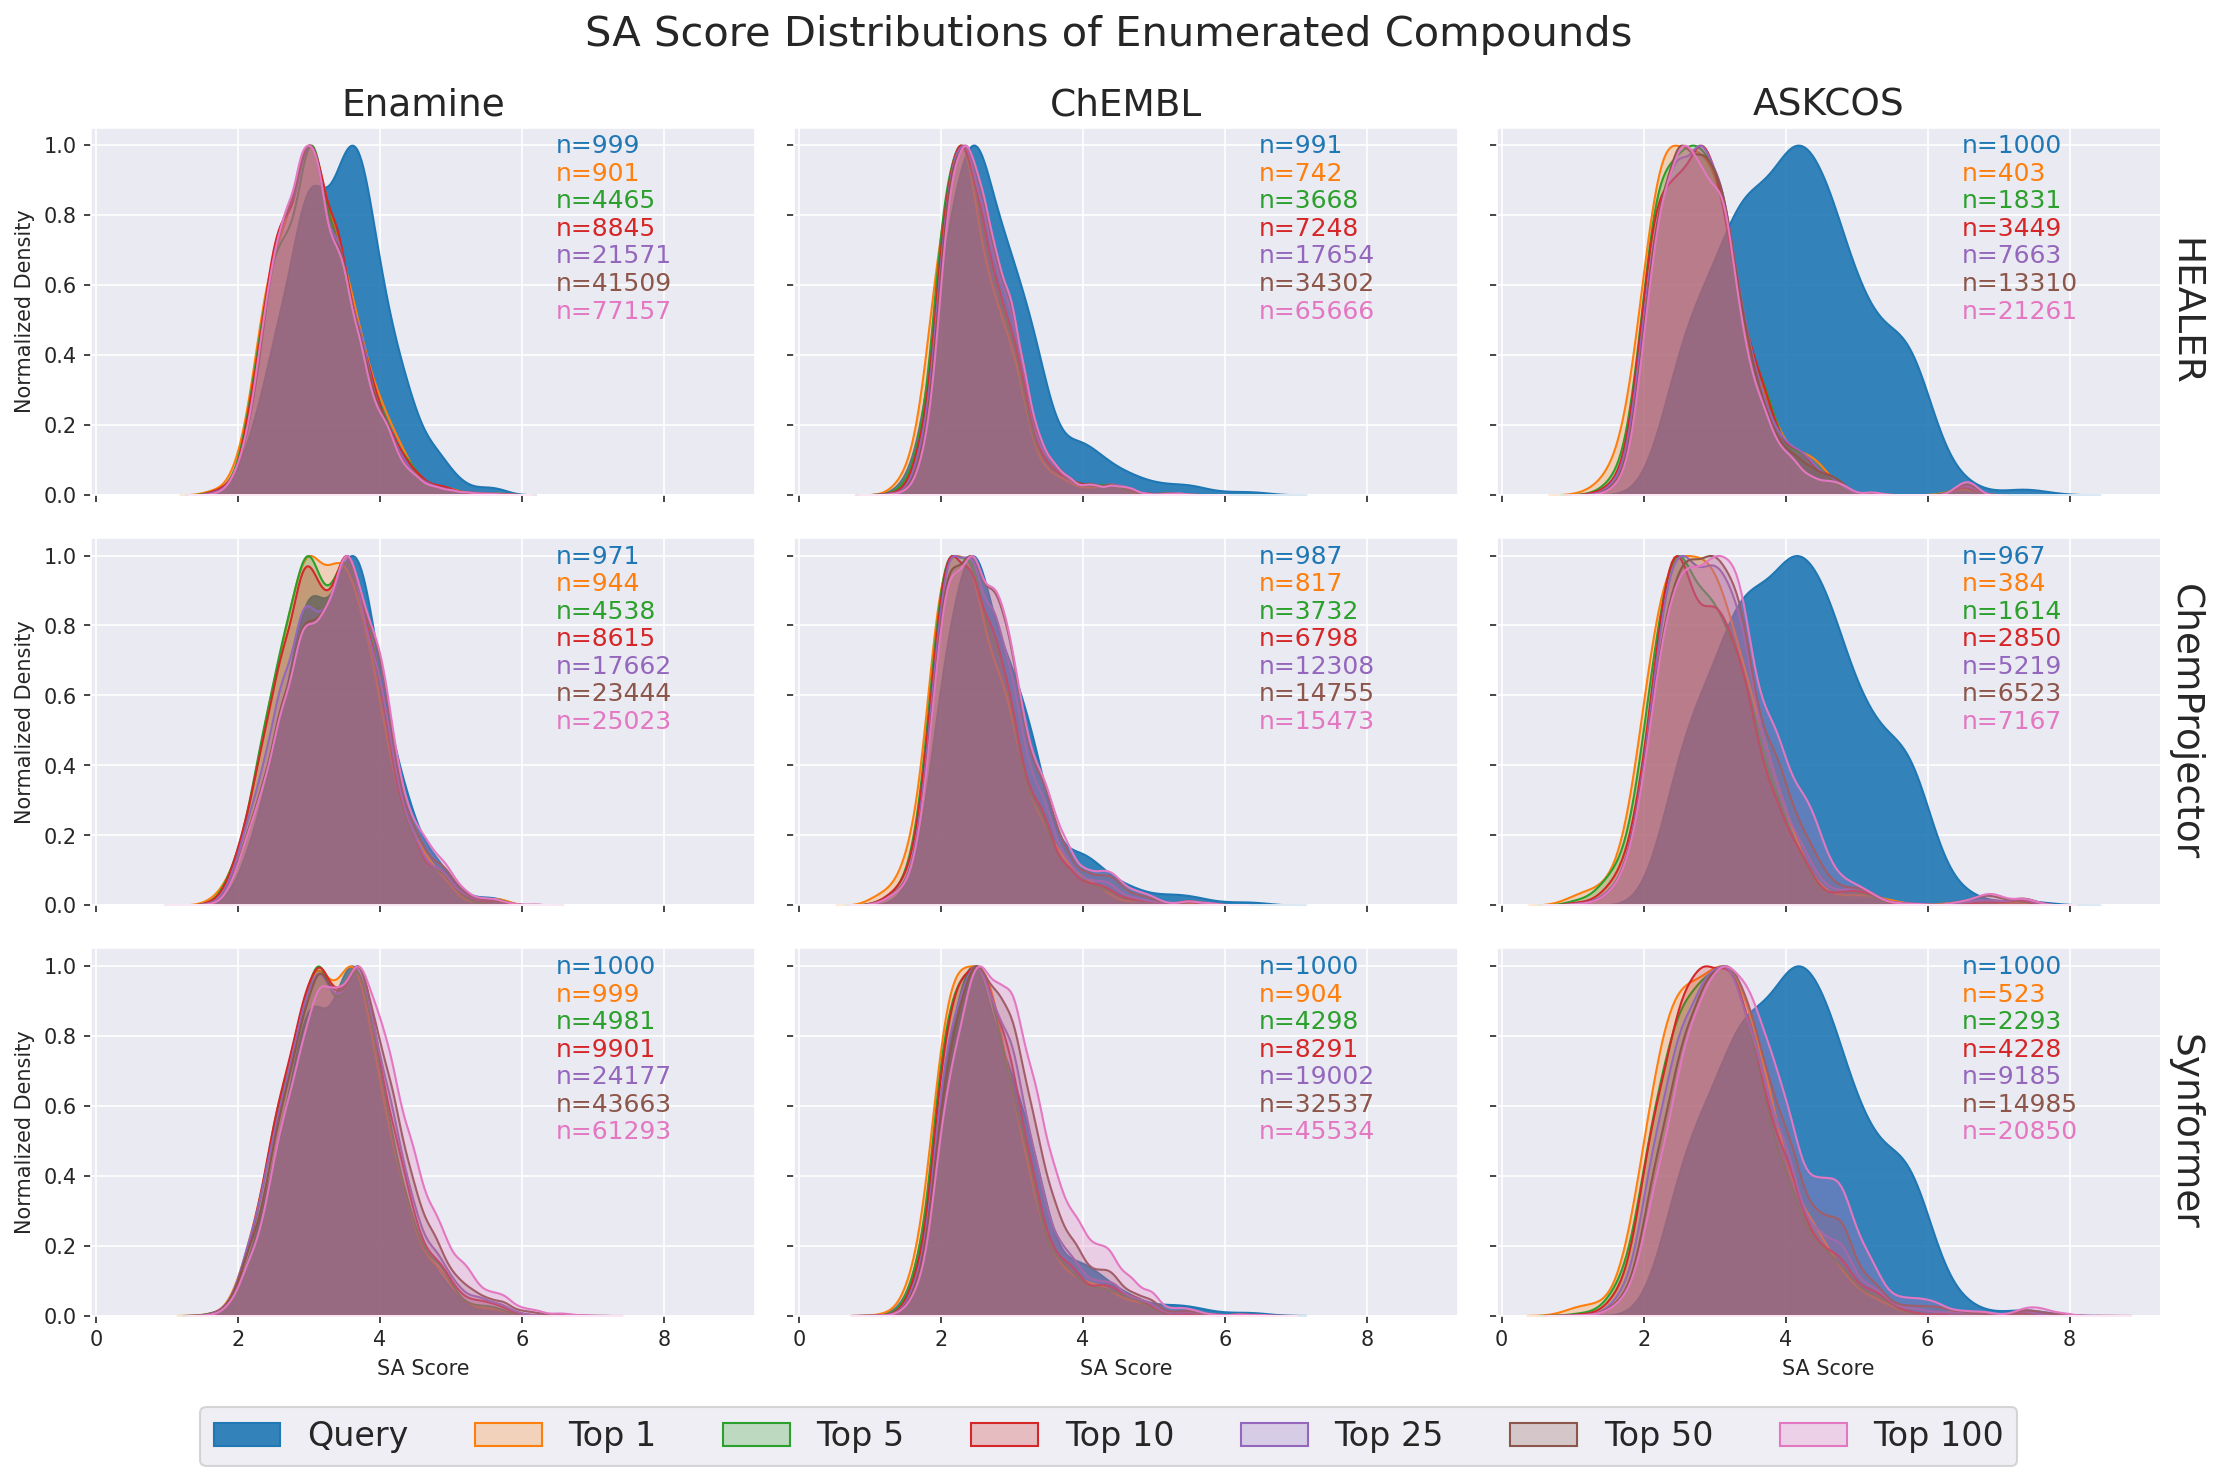

In [63]:
## plot SA score distributions
# helper plot functions
def kdeplot(data, line_number, **kwargs):
    ax = sns.kdeplot(data, **kwargs)
    if 'fill' in kwargs.keys() and kwargs['fill']==True:
        path = ax.collections[line_number].get_paths()
        ys = min_max_normalize(path[0].vertices[:, 1])
        path[0].vertices[:, 1] = ys
    else:
        line = ax.lines[line_number]
        line.set_ydata(min_max_normalize(line.get_ydata()))
    ax.set_ylim(0, 1.05)       
    ax.autoscale_view()
    return ax

def plot_sascore_distributions(dfs, labels, ax, normalize_y=True, title=None, sec_ylabel=None):
    if normalize_y:
        for i, (df, label) in enumerate(zip(dfs, labels)):
            alpha = 0.25 if label != 'Query' else 0.9
            kdeplot(df['SA_score'], i, color=f'C{i}', label=label, alpha=alpha, fill=True, ax=ax, )
    else:
        for i, (df, label) in enumerate(zip(dfs, labels)):
            alpha = 0.25 if label != 'Query' else 0.9
            sns.kdeplot(df['SA_score'], color=f'C{i}', label=label, alpha=alpha, fill=True, ax=ax)
    # annotate number of samples for each distribution
    for i, (df, label) in enumerate(zip(dfs, labels)):
        ax.annotate(f'n={len(df)}', xy=(0.70, 0.95-(i*0.075)), xycoords='axes fraction', fontsize=12,
                     ha='left', va='center', color=f'C{i}')
    ax.set_title(f'{title}', fontsize=18)
    ax.set_xlabel('SA Score')
    ax.set_ylabel('Normalized Density')
    if sec_ylabel:
        secax = ax.secondary_yaxis('right')
        secax.set_ylabel(sec_ylabel, fontsize=18, rotation=270, labelpad=20)
        secax.set_yticks([]); secax.set_yticklabels([])
    ax.legend()

# plotting
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    res_dfs = [
        healer_enamine_dfs, healer_chembl_dfs, healer_askcos_dfs,
        chemprojector_enamine_dfs, chemprojector_chembl_dfs, chemprojector_askcos_dfs,
        synformer_enamine_dfs, synformer_chembl_dfs, synformer_askcos_dfs
    ]
    distribution_labels = [
        'Query', 'Top 1', 'Top 5', 'Top 10', 'Top 25', 'Top 50', 'Top 100',
    ]
    titles = ['Enamine', 'ChEMBL', 'ASKCOS'] + [''] * 6
    row_titles = ['', '', 'HEALER'] + ['', '', 'ChemProjector'] + ['', '', 'Synformer']
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), dpi=150, sharex=True, sharey='all')
    axes = axes.flatten()
    for i, (df, title, r_title) in enumerate(zip(res_dfs, titles, row_titles)):
        ax = axes[i]
        plot_sascore_distributions(df, distribution_labels, ax, 
                                normalize_y=True, title=title, sec_ylabel=r_title)
        ax.legend_.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
            loc='lower center',
            ncol=len(labels),
            frameon=True,
            fontsize=16,)
    fig.suptitle('SA Score Distributions of Enumerated Compounds', fontsize=20)
    fig.tight_layout(pad=1.5, rect=[0, 0.05, 1, 1])


In [78]:
# test signigicance of differences between top-n and query distributions
# Alternative Hypothesis: The SA score of the enumerated compounds is significantly lower than the query compounds.
# Null Hypothesis: The SA score of the enumerated compounds is not significantly lower than the query compounds.
from scipy.stats import ttest_ind
from itertools import product

def significance_test(partition_dfs, distribution_labels):
    query_vals = partition_dfs[0]['SA_score'].values
    for i in range(1, len(partition_dfs)):
        # T-test
        t_stat, t_pval = ttest_ind(query_vals, partition_dfs[i]['SA_score'].values, alternative='greater')
        sign_level = 'ns' if t_pval > 0.05 else '*' if 0.01 < t_pval <= 0.05 else '**' if 0.001 < t_pval <= 0.01 else '***'
        print(f"T-test: {distribution_labels[i]} vs Query: statistic={t_stat:.4f}, p-value={t_pval:.4f} ({sign_level})")

labels = list(product(
    ['HEALER', 'ChemProjector', 'Synformer'],
    ['Enamine', 'ChEMBL', 'ASKCOS'],
))
for i in range(len(labels)):
    print(f"Significance results for {labels[i][0]} on {labels[i][1]}")
    significance_test(res_dfs[i], distribution_labels)
    print()


Significance results for HEALER on Enamine
T-test: Top 1 vs Query: statistic=11.6591, p-value=0.0000 (***)
T-test: Top 5 vs Query: statistic=16.0116, p-value=0.0000 (***)
T-test: Top 10 vs Query: statistic=16.7419, p-value=0.0000 (***)
T-test: Top 25 vs Query: statistic=17.6132, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=18.1644, p-value=0.0000 (***)
T-test: Top 100 vs Query: statistic=18.9113, p-value=0.0000 (***)

Significance results for HEALER on ChEMBL
T-test: Top 1 vs Query: statistic=10.9170, p-value=0.0000 (***)
T-test: Top 5 vs Query: statistic=14.8790, p-value=0.0000 (***)
T-test: Top 10 vs Query: statistic=15.0219, p-value=0.0000 (***)
T-test: Top 25 vs Query: statistic=14.5537, p-value=0.0000 (***)
T-test: Top 50 vs Query: statistic=13.8084, p-value=0.0000 (***)
T-test: Top 100 vs Query: statistic=13.4039, p-value=0.0000 (***)

Significance results for HEALER on ASKCOS
T-test: Top 1 vs Query: statistic=24.9975, p-value=0.0000 (***)
T-test: Top 5 vs Query: stati

# Drug-Likeliness Analysis

# Computational Performance


/tmp/ipykernel_18338/3784411811.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_18338/3784411811.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')


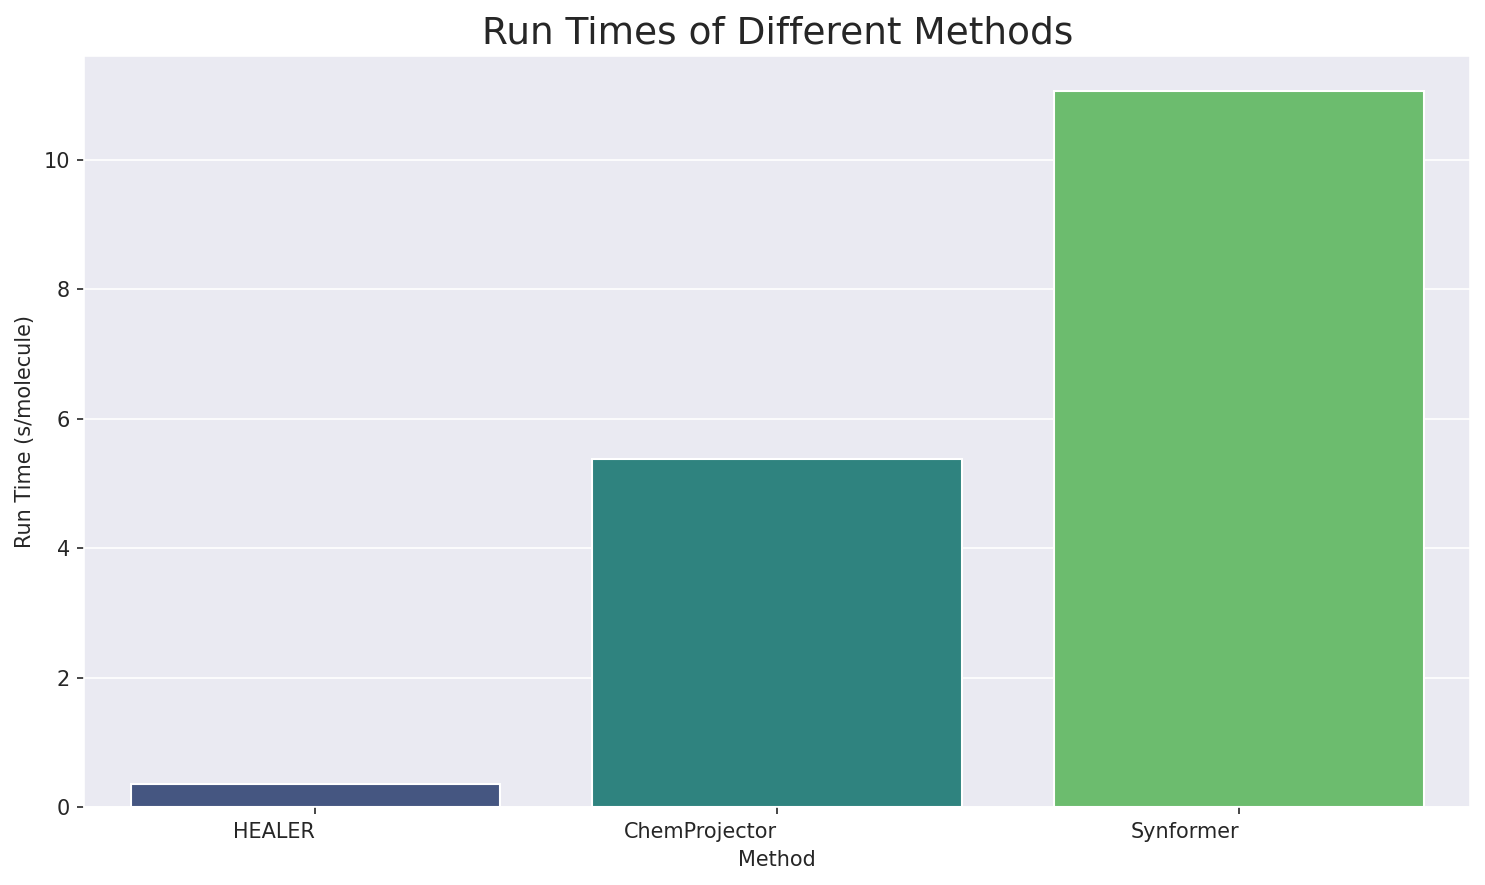

In [7]:
run_times = { # in seconds per single enumeration
    'HEALER': [0.35],
    'ChemProjector': [5.38],
    'Synformer': [11.06],
}
def plot_run_times(run_times, labels, ax):
    sns.barplot(
        x=labels,
        y=[np.mean(times) for times in run_times.values()],
        ax=ax,
        palette='viridis',
    )
    ax.set_ylabel('Run Time (s/molecule)')
    
# plotting run times
with sns.axes_style("darkgrid", rc={"xtick.bottom": True, "ytick.left": True}):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    plot_run_times(run_times, list(run_times.keys()), ax)
    ax.set_title('Run Times of Different Methods', fontsize=18)
    ax.set_xlabel('Method')
    ax.set_xticklabels(ax.get_xticklabels(), ha='right')
    plt.tight_layout()
    plt.show()
